In [1]:
import cu_rsc as cr
cr.setup_tables()
import numpy as np
import cupy as cp
import cupyx
import matplotlib.pyplot as plt
from cycler import cycler
plt.style.use("aps.mplstyle")
import matplotlib as mpl
mpl.rcParams['axes.prop_cycle'] = cycler(
    'color',
    ['#1b9e77', '#d95f02', '#7570b3', '#e7298a',
     '#66a61e', '#e6ab02', '#a6761d', '#666666']
)
M_dev = cr.load_m_table_device()        # upload to GPU
res   = cr.resources_from_config(M_dev)

### Matrix element

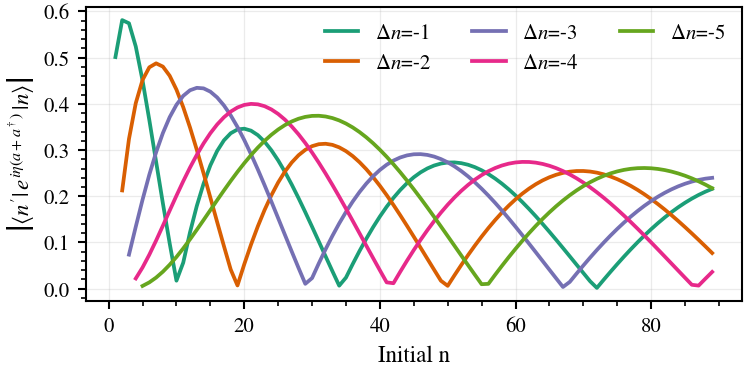

In [22]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

n_range = 90
delta_ns = np.array([-1, -2, -3, -4, -5], dtype=int)

plt.figure(figsize=(5, 2.5))

for delta_n in delta_ns:
    # indices must be ints
    n_init = cp.arange(-delta_n, n_range, dtype=cp.int32)

    # vectorized gather on GPU
    vals = res.M[n_init, n_init + delta_n, 60]   # CuPy array

    # convert once for matplotlib
    x = cp.asnumpy(n_init)
    y = cp.asnumpy(vals)

    plt.plot(x, np.abs(y),label=f"$\\Delta n$={delta_n}")

plt.legend(frameon=False, ncol=3)
plt.xlabel("Initial n")
plt.ylabel(r"$\left|\langle n'|\,e^{i\eta(a+a^\dagger)}\,|n\rangle\right|$")
plt.tick_params(axis='both', which='major')
plt.savefig("RSC_sim_cool_matrix.pdf", bbox_inches="tight")

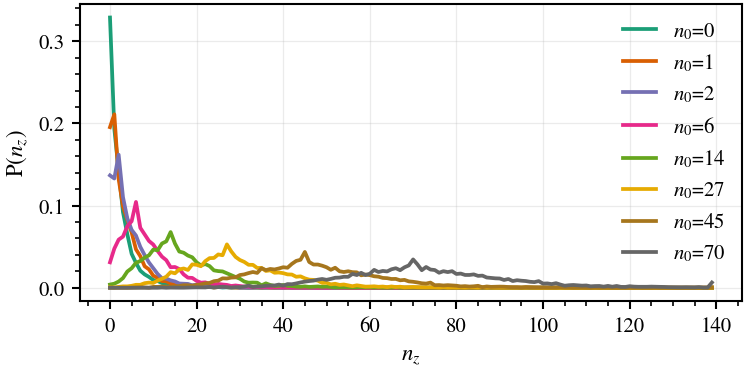

In [21]:
from cu_rsc.RSC_functions import optical_pumping
n_inits = np.array([0, 1, 2, 6, 14, 27, 45, 70], dtype=np.int32)
n_range = 140
n_vals = np.arange(n_range)

Nmc = 10000  # Monte Carlo samples per initial state

plt.figure(figsize=(5, 2.5))

for n_init in n_inits:
    # IMPORTANT: molecules must be int32 with shape (N,6)
    mol = cp.zeros((Nmc, 8), dtype=cp.int32)
    mol[:, 2] = int(n_init)   # nz
    mol[:, 3] = -1            # state (so OP is active)
    mol[:, 4] = 0             # spin good
    mol[:, 5] = 0             # not lost

    # One optical pumping cycle
    optical_pumping(mol, res, K_max=12)

    # Keep only survivors if you want a conditional distribution
    surv = (mol[:, 5] == 0)
    nz = mol[surv, 2]

    # Histogram on GPU then move to CPU for plotting
    counts = cp.bincount(cp.clip(nz, 0, n_range - 1), minlength=n_range).astype(cp.float64)
    denom = int(surv.sum().get())
    prob = (counts / max(denom, 1)).get()

    plt.plot(n_vals, prob, label="$n_0$" + f"={n_init}")

plt.xlabel("$n_z$")
plt.ylabel("P($n_z$)")
plt.tick_params(axis='both', which='major')
plt.legend(frameon=False)
plt.savefig("RSC_sim_op_prob.pdf", bbox_inches="tight")

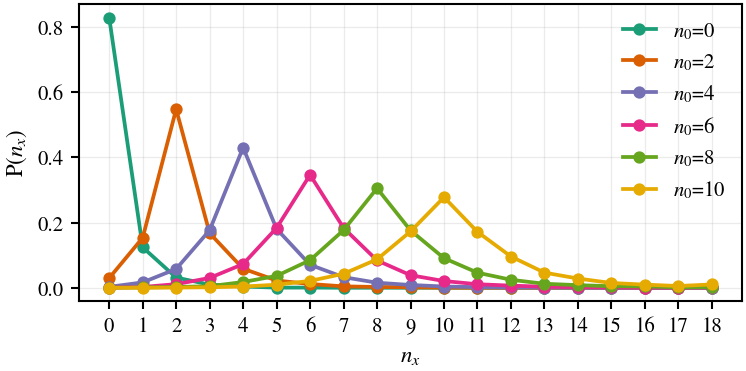

In [7]:
from cu_rsc.RSC_functions import optical_pumping
n_inits = np.array([0, 2, 4, 6, 8, 10], dtype=np.int32)
n_range = 19
n_vals = np.arange(n_range)

Nmc = 10000  # Monte Carlo samples per initial state

plt.figure(figsize=(5, 2.5))

for n_init in n_inits:
    # IMPORTANT: molecules must be int32 with shape (N,6)
    mol = cp.zeros((Nmc, 8), dtype=cp.int32)
    mol[:, 0] = int(n_init)   # nz
    mol[:, 3] = -1            # state (so OP is active)
    mol[:, 4] = 0             # spin good
    mol[:, 5] = 0             # not lost

    # One optical pumping cycle
    optical_pumping(mol, res, K_max=12)

    # Keep only survivors if you want a conditional distribution
    surv = (mol[:, 5] == 0)
    nx = mol[surv, 0]

    # Histogram on GPU then move to CPU for plotting
    counts = cp.bincount(cp.clip(nx, 0, n_range - 1), minlength=n_range).astype(cp.float64)
    denom = int(surv.sum().get())
    prob = (counts / max(denom, 1)).get()

    plt.plot(n_vals, prob, 'o-', label="$n_0$" + f"={n_init}")

plt.xlabel("$n_x$")
plt.ylabel("P($n_x$)")
plt.minorticks_off()
plt.tick_params(axis='both', which='major')
plt.legend(frameon=False)
from matplotlib.ticker import MultipleLocator
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))
plt.savefig("RSC_sim_op_prob_x.pdf", bbox_inches="tight")

### Initial distribution

In [18]:
temp = [25e-6, 25e-6, 25e-6]
mol_ref = cr.build_thermal_molecules(100000, temp)
dist_ref = cr.get_n_distribution_gpu(mol_ref, max_bins=10, plot=(False, False, False))

In [19]:
data_x = dist_ref[0]
data_z = dist_ref[2]

# Sort data
n_x = np.array(sorted(data_x.keys()))
dis_x = np.array([data_x[k] for k in n_x], dtype=float)

n_z = np.array(sorted(data_z.keys()))
dis_z = np.array([data_z[k] for k in n_z], dtype=float)


# Normalize
dis_x /= dis_x.sum()
dis_z   /= dis_z.sum()


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Interpolation
f_x = interp1d(n_x, dis_x, kind='linear', fill_value="extrapolate")
f_z   = interp1d(n_z,   dis_z,   kind='linear', fill_value="extrapolate")

# Common dense n-axis for smooth plotting

n_min = min(n_x.min(), n_z.min())
n_max = 200
n_dense = np.linspace(n_min, n_max, 500)
dis_x_dense = f_x(n_dense)
dis_z_dense = f_z(n_dense)
# Avoid small negative values from extrapolation/interpolation
dis_x_dense = np.clip(dis_x_dense, 0, None)
dis_z_dense = np.clip(dis_z_dense, 0, None)

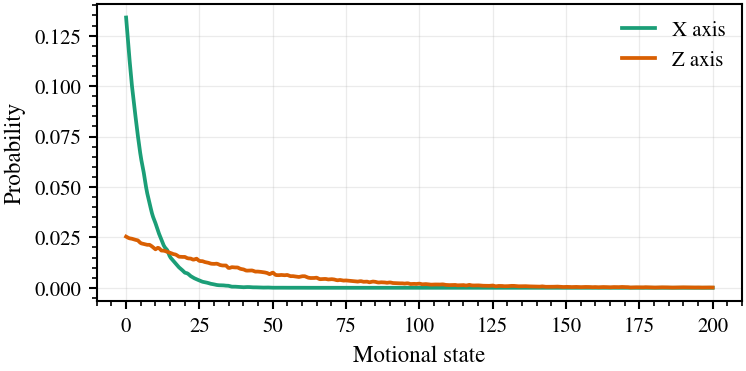

In [39]:
# --- X distribution ---
plt.figure(figsize=(5, 2.5))
plt.plot(n_dense, dis_x_dense, label="X axis", color='C0')
plt.plot(n_dense, dis_z_dense, label="Z axis", color='C1')
plt.xlabel("Motional state")
plt.ylabel("Probability")
plt.legend(frameon=False)
plt.savefig("RSC_initial_distribution.pdf", bbox_inches="tight")


Text(0, 0.5, 'Probability')

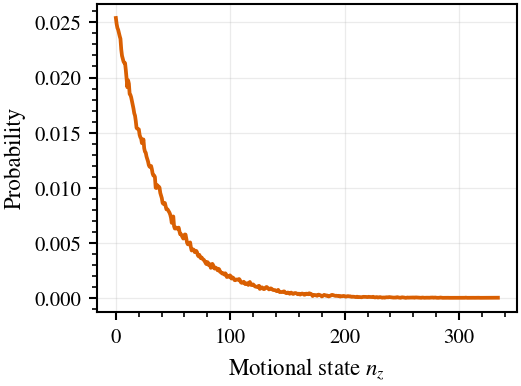

In [22]:
# --- Z distribution ---
plt.figure()
plt.plot(n_z_dense, dis_z_dense, label="Z thermal distribution", color='C1')
plt.xlabel("Motional state $n_x$")
plt.ylabel("Probability")

### Cooling performance experiment original

Raman pulses: 100%|██████████| 200/200 [00:56<00:00,  3.56it/s]
/n/home02/lyuqinshu/cu_rsc/src/cu_rsc/analysis.py:84: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


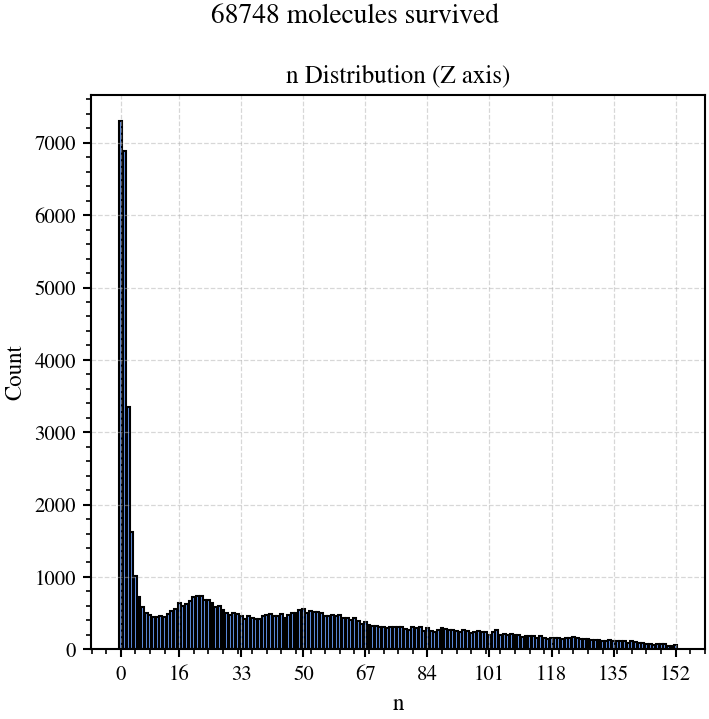

In [2]:
seq_exp = np.load("runs/seq_exp.npy")
temp = [25e-6, 25e-6, 25e-6]
trap_detuning_sigma = 0.5e3
carrier_detuning_sigma = 0.0e3
mol_exp = cr.build_thermal_molecules(100000, temp, 
                                     trap_detuning_sigma=trap_detuning_sigma, 
                                     carrier_detuning_sigma=carrier_detuning_sigma)
cr.raman_cool_with_pumping(mol_exp, seq_exp[:-80], res, show_progress=True)
dist_exp = cr.get_n_distribution_gpu(mol_exp, max_bins=10, plot=(False, False, True))
result_exp = cr.bootstrap_stats_from_molecules(mol_exp)

In [3]:
temp = [25e-6, 25e-6, 25e-6]
mol_ref = cr.build_thermal_molecules(100000, temp, 
                                     trap_detuning_sigma=trap_detuning_sigma,
                                    carrier_detuning_sigma=carrier_detuning_sigma)
dist_ref = cr.get_n_distribution_gpu(mol_ref, max_bins=10, plot=(False, False, False))

Raman pulses: 100%|██████████| 140/140 [00:37<00:00,  3.72it/s]


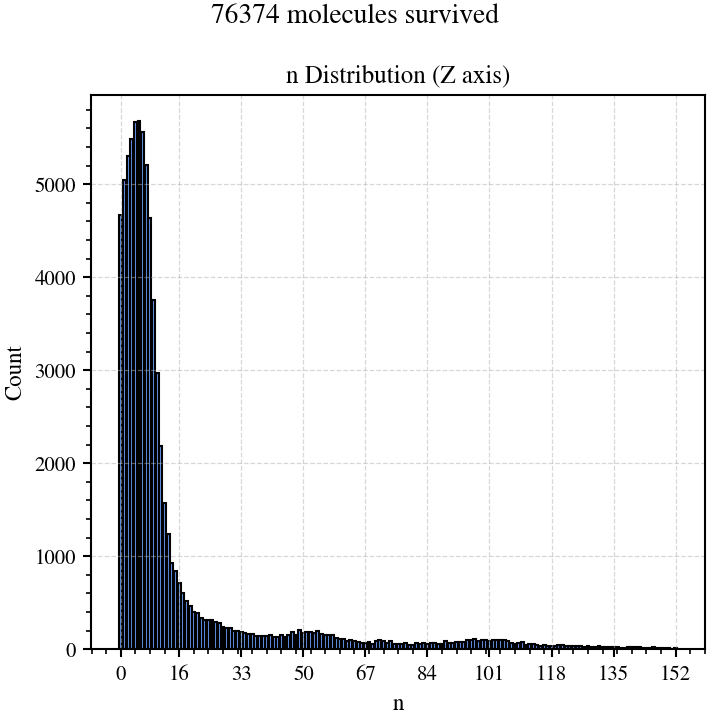

In [4]:
# seq_op = np.load("runs/seq_op.npy")
seq_op = np.load("runs/seq_cap_0406.npy")[:140]
temp = [25e-6, 25e-6, 25e-6]
trap_detuning_sigma = 0.5e3
carrier_detuning_sigma = 0.0e3
mol_op = cr.build_thermal_molecules(100000, temp, 
                                     trap_detuning_sigma=trap_detuning_sigma, 
                                     carrier_detuning_sigma=carrier_detuning_sigma)
cr.raman_cool_with_pumping(mol_op, seq_op, res, show_progress=True)
dist_op = cr.get_n_distribution_gpu(mol_op, max_bins=10, plot=(False, False, True))
result_op = cr.bootstrap_stats_from_molecules(mol_op)

In [46]:
import numpy as np
from scipy.interpolate import interp1d

def get_axis_distribution(dist_exp, dist_ref, dist_op, axis, n_points=500):
    data_exp = dist_exp[axis]
    data_ref = dist_ref[axis]
    data_op  = dist_op[axis]

    x_exp = np.array(sorted(data_exp.keys()))
    y_exp = np.array([data_exp[k] for k in x_exp], dtype=float)

    x_ref = np.array(sorted(data_ref.keys()))
    y_ref = np.array([data_ref[k] for k in x_ref], dtype=float)

    x_op = np.array(sorted(data_op.keys()))
    y_op = np.array([data_op[k] for k in x_op], dtype=float)

    y_exp /= y_exp.sum()
    y_ref /= y_ref.sum()
    y_op  /= y_op.sum()

    f_exp = interp1d(x_exp, y_exp, kind="linear", fill_value="extrapolate")
    f_ref = interp1d(x_ref, y_ref, kind="linear", fill_value="extrapolate")
    f_op  = interp1d(x_op,  y_op,  kind="linear", fill_value="extrapolate")

    x_min = min(x_exp.min(), x_ref.min(), x_op.min())
    x_max = max(x_exp.max(), x_ref.max(), x_op.max())

    x_dense = np.linspace(x_min, x_max, n_points)

    y_exp_smooth = np.clip(f_exp(x_dense), 0, None)
    y_ref_smooth = np.clip(f_ref(x_dense), 0, None)
    y_op_smooth  = np.clip(f_op(x_dense), 0, None)

    return x_dense, y_exp_smooth, y_ref_smooth, y_op_smooth


# Get x, y, z axes
axis_results = [
    get_axis_distribution(dist_exp, dist_ref, dist_op, axis)
    for axis in range(3)
]

# Stack into 3 × N arrays
x_dense_all = np.array([r[0] for r in axis_results])
y_exp_all   = np.array([r[1] for r in axis_results])
y_ref_all   = np.array([r[2] for r in axis_results])
y_op_all    = np.array([r[3] for r in axis_results])

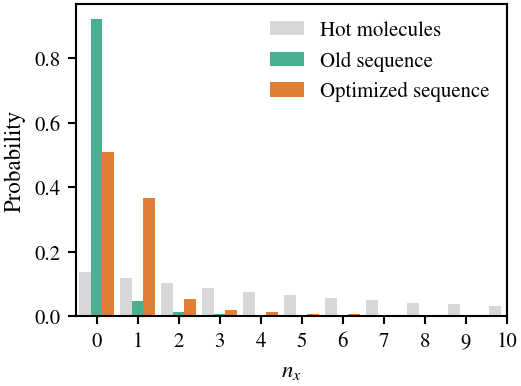

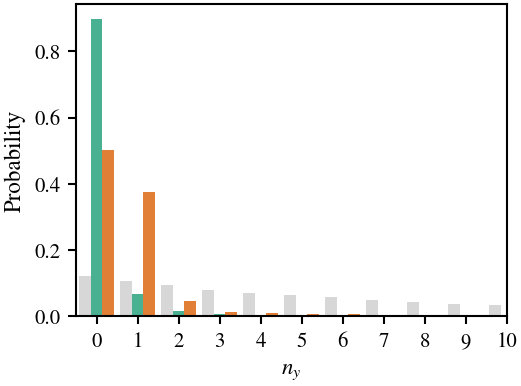

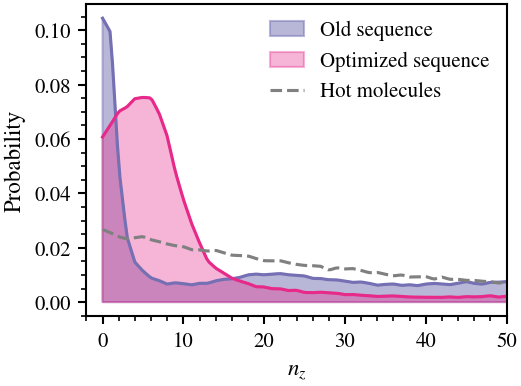

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.ticker import MultipleLocator

axis_labels = [r"$n_x$", r"$n_y$", r"$n_z$"]
axis_names = ["x", "y", "z"]

for axis in range(3):

    # Original distributions
    data_exp = dist_exp[axis]
    data_ref = dist_ref[axis]
    data_op  = dist_op[axis]

    x_exp = np.array(sorted(data_exp.keys()))
    y_exp = np.array([data_exp[k] for k in x_exp], dtype=float)
    y_exp /= y_exp.sum()

    x_ref = np.array(sorted(data_ref.keys()))
    y_ref = np.array([data_ref[k] for k in x_ref], dtype=float)
    y_ref /= y_ref.sum()

    x_op = np.array(sorted(data_op.keys()))
    y_op = np.array([data_op[k] for k in x_op], dtype=float)
    y_op /= y_op.sum()

    plt.figure()

    if axis < 2:

        # Side-by-side bars
        bar_width = 0.28

        plt.bar(
            x_ref - bar_width,
            y_ref,
            width=bar_width,
            color="lightgray",
            alpha=0.9,
            label="Hot molecules",
        )

        plt.bar(
            x_exp,
            y_exp,
            width=bar_width,
            color="C0",
            alpha=0.8,
            label="Old sequence",
        )

        plt.bar(
            x_op + bar_width,
            y_op,
            width=bar_width,
            color="C1",
            alpha=0.8,
            label="Optimized sequence",
        )
        plt.xlim((-0.5, 10))
        ax = plt.gca()
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.minorticks_off()

    else:

        x_dense = axis_results[axis][0]
        y_exp_smooth = axis_results[axis][1]
        y_ref_smooth = axis_results[axis][2]
        y_op_smooth  = axis_results[axis][3]

        plt.fill_between(
            x_dense,
            0,
            y_exp_smooth,
            color="C2",
            alpha=0.5,
            label="Old sequence",
        )

        plt.plot(
            x_dense,
            y_exp_smooth,
            color="C2",
            linewidth=1.5,
        )

        plt.fill_between(
            x_dense,
            0,
            y_op_smooth,
            color="C3",
            alpha=0.35,
            label="Optimized sequence",
        )

        plt.plot(
            x_dense,
            y_op_smooth,
            color="C3",
            linewidth=1.5,
        )

        plt.plot(
            x_dense,
            y_ref_smooth,
            "--",
            color="Gray",
            linewidth=1.5,
            label="Hot molecules",
        )

        plt.xlim((-2, 50))

    plt.xlabel(axis_labels[axis])
    plt.ylabel("Probability")
    plt.grid(False)

    if axis == 0 or axis == 2:
        plt.legend(frameon=False)

    plt.savefig(
        f"thesis_plot/distribution_{axis_names[axis]}.pdf",
        bbox_inches="tight",
    )

    plt.show()

In [5]:
zt_freqs = cp.linspace(-40e3, 20e3, 1000)
zt_rabi = 1.01e3
zt_pulse = 500e-6
temp = [25e-6, 25e-6, 25e-6]

frequencys, polarizations_exp = cr.raman_sideband_thermometry(
    molecules_dev=mol_exp,
    axis=2,
    frequencys=zt_freqs,
    rabi_freq=zt_rabi,
    pulse_time=zt_pulse,
    res=res,
    k_max=2
)

frequencys, polarizations_op = cr.raman_sideband_thermometry(
    molecules_dev=mol_op,
    axis=2,
    frequencys=zt_freqs,
    rabi_freq=zt_rabi,
    pulse_time=zt_pulse,
    res=res,
    k_max=2
)

Raman thermometry: 100%|██████████| 1000/1000 [00:07<00:00, 139.95it/s]


(-1.0, -0.3)

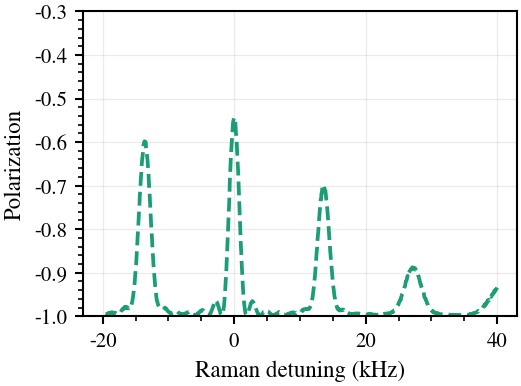

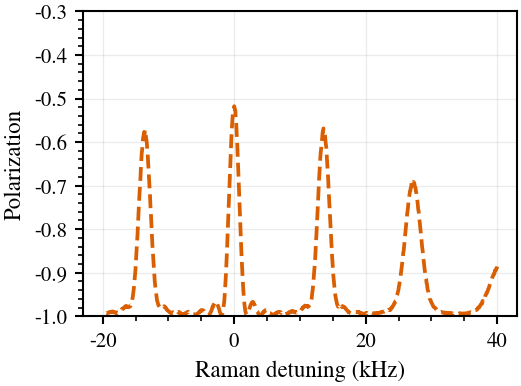

In [6]:
plt.figure()

plt.plot(
    -cp.asnumpy(frequencys*1e-3), 
    cp.asnumpy(polarizations_exp), 
    '--',
    color='C0',
    )
plt.xlabel("Raman detuning (kHz)")
plt.ylabel("Polarization")
plt.ylim((-1, -0.3))

plt.figure()

plt.plot(
    -cp.asnumpy(frequencys*1e-3), 
    cp.asnumpy(polarizations_op), 
    '--',
    color='C1',
    )

plt.xlabel("Raman detuning (kHz)")
plt.ylabel("Polarization")
plt.ylim((-1, -0.3))

# plt.savefig("RST_comparison.pdf", bbox_inches="tight")

In [71]:
def visualize_sequence(seq, show_time_color: bool = False, title: str | None = None, file_name: str | None = None) -> None:
    
    # Convert CuPy → NumPy if needed
    if not isinstance(seq, np.ndarray):
        try:
            import cupy as cp
            if isinstance(seq, cp.ndarray):
                seq = cp.asnumpy(seq)
            else:
                raise TypeError("seq must be a NumPy or CuPy array.")
        except ImportError:
            raise TypeError("seq must be a NumPy array or CuPy array (CuPy not installed).")

    if seq.ndim != 2 or seq.shape[1] not in (3, 4, 5):
        raise ValueError(f"Invalid sequence shape {seq.shape}, expected (P,3), (P,4), or (P,5).")

    P, C = seq.shape
    axes = seq[:, 0].astype(int)
    delta_n = seq[:, 1].astype(int)

    if C == 3:
        times = seq[:, 2].astype(float)
    elif C == 4:
        times = seq[:, 3].astype(float)
    else:  # C == 5
        times = seq[:, 3].astype(float)

    pulse_idx = np.arange(P)

    plt.figure(figsize=(2.5, 6))

    if show_time_color:
        sc = plt.scatter(delta_n, pulse_idx, c=times)
        plt.colorbar(sc, label="Pulse duration (s)")
    else:
        colors = {0: "C0", 1: "C1", 2: "C2"}
        labels = {0: "X", 1: "Y", 2: "Z"}
    
        for axv in np.unique(axes):
            mask = axes == axv
            plt.scatter(
                delta_n[mask],
                pulse_idx[mask],
                label=f"Axis {labels.get(axv, axv)}",
                color=colors.get(axv, "gray"),
                s=40,
                alpha=0.9,
                edgecolor="k",
            )
    
        plt.legend(frameon=False)
    
    ax = plt.gca()
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.minorticks_off()
    ax.invert_yaxis()
    
    plt.xlabel("Δn")
    plt.ylabel("Pulse index")
    plt.grid(True, linestyle="--")
    
    plt.title(title if title is not None else "Raman Sequence")
    plt.savefig(
        file_name if file_name is not None else "Raman_Sequence.pdf",
        bbox_inches="tight"
    )
    plt.show()


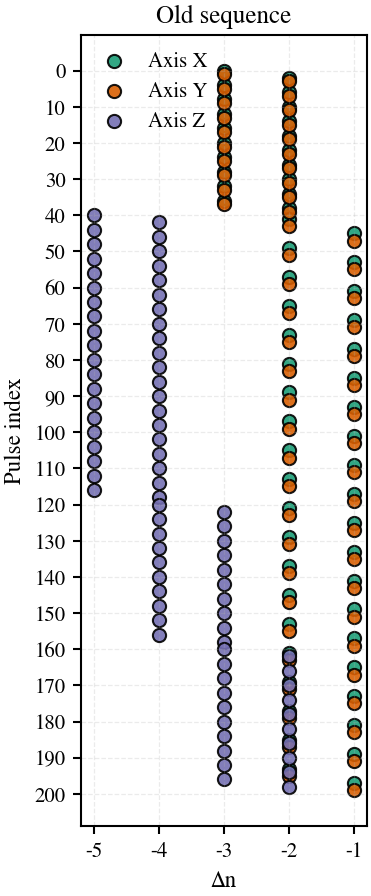

In [72]:
visualize_sequence(seq_exp[:200], title="Old sequence", file_name="thesis_plot/old_seq_visualize.pdf")

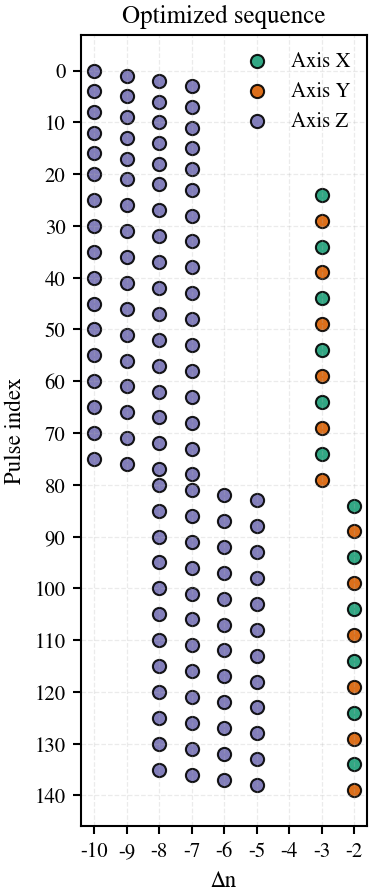

In [73]:
visualize_sequence(seq_op, title="Optimized sequence", file_name="thesis_plot/opt_seq_visualize.pdf")

In [18]:
np.savez(
    "thesis_plot/RST_exp.npz",
    detuning_kHz=-cp.asnumpy(frequencys * 1e-3),
    polarization=cp.asnumpy(polarizations_exp),
)
np.savez(
    "thesis_plot/RST_ref.npz",
    detuning_kHz=-cp.asnumpy(frequencys * 1e-3),
    polarization=cp.asnumpy(polarizations_ref),
)

### Scan $\Omega$

In [27]:
from tqdm import tqdm
omega_xs = np.linspace(0.1, 2, 40)
seq_op = np.load("runs/seq_cap_0406.npy")[:140]
temp = [25e-6, 25e-6, 25e-6]
trap_detuning_sigma = 0.5e3
carrier_detuning_sigma = 0.0e3
xy_cap = 3
z_cap = 10
num_mol = 10000
rates = []

for omega in tqdm(omega_xs):
    
    mol_op = cr.build_thermal_molecules(num_mol, temp, 
                                         trap_detuning_sigma=trap_detuning_sigma, 
                                         carrier_detuning_sigma=carrier_detuning_sigma)
    cr.raman_cool_with_pumping(mol_op, seq_op, res, show_progress=False, 
                               Rabi_scale=[omega,omega,1])
    dist_op = cr.get_n_distribution_gpu(mol_op, max_bins=10, plot=(False, False, False))
    valid_mask = (mol_op[:, 4] == 0) & (mol_op[:, 3] == 1) & (mol_op[:, 5] == 0)
    target_mask = (
        valid_mask & (mol_op[:, 0] <= xy_cap) & (mol_op[:, 1] <= xy_cap) & (mol_op[:, 2] <= z_cap)
    )
    n_target = int(cp.sum(target_mask).get())
    rate = n_target / num_mol
    rates.append(rate)
rates=np.array(rates)

100%|██████████| 40/40 [06:41<00:00, 10.04s/it]


In [24]:
from tqdm import tqdm
omega_zs = np.linspace(0.1, 2, 40)
seq_op = np.load("runs/seq_cap_0406.npy")[:140]
temp = [25e-6, 25e-6, 25e-6]
trap_detuning_sigma = 0.5e3
carrier_detuning_sigma = 0.0e3
xy_cap = 3
z_cap = 10
num_mol = 10000
rates_z = []

for omega in tqdm(omega_xs):
    
    mol_op = cr.build_thermal_molecules(num_mol, temp, 
                                         trap_detuning_sigma=trap_detuning_sigma, 
                                         carrier_detuning_sigma=carrier_detuning_sigma)
    cr.raman_cool_with_pumping(mol_op, seq_op, res, show_progress=False, 
                               Rabi_scale=[1,1,omega])
    dist_op = cr.get_n_distribution_gpu(mol_op, max_bins=10, plot=(False, False, False))
    valid_mask = (mol_op[:, 4] == 0) & (mol_op[:, 3] == 1) & (mol_op[:, 5] == 0)
    target_mask = (
        valid_mask & (mol_op[:, 0] <= xy_cap) & (mol_op[:, 1] <= xy_cap) & (mol_op[:, 2] <= z_cap)
    )
    n_target = int(cp.sum(target_mask).get())
    rate = n_target / num_mol
    rates_z.append(rate)
rates_z=np.array(rates_z)

100%|██████████| 40/40 [06:32<00:00,  9.82s/it]


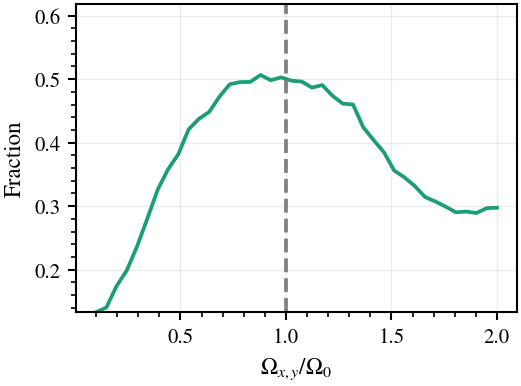

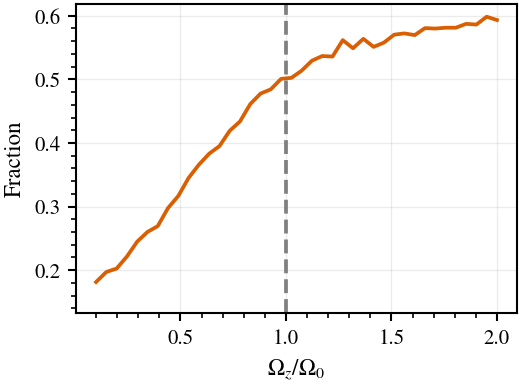

In [31]:
ymin = min(np.min(rates), np.min(rates_z))
ymax = max(np.max(rates), np.max(rates_z)) + 0.02

# XY scan
plt.figure()
plt.plot(omega_xs, rates, color='C0')
plt.xlabel(r"$\Omega_{x,y}/\Omega_0$")
plt.ylabel("Fraction")
plt.ylim(ymin, ymax)
plt.axvline(
    x=1,
    color='gray',
    linestyle='--',
)
plt.savefig("thesis_plot/XY_power_scan.pdf", bbox_inches="tight")
plt.show()

# Z scan
plt.figure()
plt.plot(omega_zs, rates_z, color='C1')
plt.xlabel(r"$\Omega_z/\Omega_0$")
plt.ylabel("Fraction")
plt.ylim(ymin, ymax)
plt.axvline(
    x=1,
    color='gray',
    linestyle='--',
)
plt.savefig("thesis_plot/Z_power_scan.pdf", bbox_inches="tight")
plt.show()